In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
# Single function imports
from scipy.integrate import quad, dblquad

In [3]:
from warnings import warn
from matplotlib import rcParams
rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",            # Computer Modern math
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": True,
})

# Integral when intersection is an overlapping region

## Exact integral by swapping the order of integration

We previously derived the following expression where $● :=B_2(x;\varepsilon) \cap B_2(0;1)$ and $a = \|x\|$:
\begin{align*}
    G_\varepsilon (x) &= \frac{1}{2\pi} \int\limits_{ x - ● } \log |y| \,\mathrm{d}y
    =
    \begin{cases}
        \dfrac{\varepsilon^2}{4}(\log \varepsilon^2 - 1) & \text{if } x \in \overline{B}(0;1-\varepsilon),
        \\
        \dfrac{\pi - \varphi}{4\pi} \varepsilon^2 ( \log \varepsilon^2 - 1) + 2 F_\varepsilon (a,\varphi)  & \text{if } \mathrm{d}\big(x, \partial B(0;1) \big) \in [0,1-\varepsilon),
    \end{cases}
\end{align*}
To compute the second case, let $\varphi = \arccos \left( \dfrac{1 - a^2 - \varepsilon^2}{2a\varepsilon} \right)$ and $s(\theta) = -a \cos(\theta) + \sqrt{ 1 - a^2 \sin^2(\theta) }$, then 
\begin{align*}
    F_\varepsilon (a,\varphi) &= \frac{\varphi}{8\pi} s^2(\varphi) \big( \log s^2(\varphi) - 1\big) - h_1(a;r) \Big|_{r=1-a}^{r=s(\varphi)},
    \\
    h_1(a; r) 
    &= \frac{1}{8\pi} \left[ r^2 (\log r^2 -1) \operatorname{arccos} \left(\dfrac{1- a^2 - r^2}{2 a r}\right)  +  h_2\big(a;\chi(a;r) \big) \right],
    \\
    h_2(a; \phi) 
    &= 
    2 \Im \big( \mathrm{Li}_2 ( a e^{i \phi} ) \big)
        + (1-a^2)\left[ \phi + \arctan\left(\frac{a\sin\phi}{1-a\cos\phi}\right)\right] + a\big( \log(1-2a\cos\phi+a^2) - 2 \big)\sin\phi ;
\end{align*}
and finally $\chi(a;r) = \arccos \left(\dfrac{1 + a^2 - r^2}{2a} \right)$.

In [4]:
import sympy as sp
from scipy.special import spence # Use as spece(1.0-z)

In [5]:
def h_2(a, ϕ):
    # Dilog part
    h_2a = 2.0 * spence( 1.0 - a * np.exp( 1j * ϕ) ).imag
    # Angular part
    h_2b = (1.0 - a**2) * ( ϕ + np.arctan2(a * np.sin(ϕ), 1.0 - a * np.cos(ϕ)) )
    # Sine part
    y_a = (1 - a)**2 + 4.0 * a * np.sin(0.5 * ϕ)**2        # 0 when (a,ϕ) = (1,0)
    y_b = np.zeros_like(y_a)
    np.log(y_a, out = y_b, where = (y_a > 0))              # log(0) is 0 for limit to work
    h_2c = a * ( y_b - 2.0 ) * np.sin(ϕ)
    
    return h_2a + h_2b + h_2c

In [6]:
def h_1(a, r):
    a = np.asarray(a)
    r = np.asarray(r)
    
    ''' Angular part '''
    y = np.zeros_like(r)
    np.reciprocal(r, out = y, where = (r > 0))   
    
    ψ_1 = 0.5 * (1.0 - a**2 - r**2) * y / a      # Argument for first term
    ψ_2 = 0.5 * (1.0 + a**2 - r**2) / a          # Argument for change of variables in second term
    
    # Correct any machine error
    '''if ( abs(ψ_1) > 1.0).any():
        if (abs( abs(ψ_1)[abs(ψ_1) > 1.0] - 1.0 ) < 1e-15).any():
            ψ_1[abs(ψ_1) > 1.0] = np.clip( ψ_1[abs(ψ_1) > 1.0], -1.0, 1.0 )
    if ( abs(ψ_2) > 1.0).any():
        if (abs( abs(ψ_2)[abs(ψ_2) > 1.0] - 1.0 ) < 1e-15).any():
            ψ_2[abs(ψ_2) > 1.0] = np.clip( ψ_2[abs(ψ_2) > 1.0], -1.0, 1.0 )'''
    np.clip( ψ_1, -1.0, 1.0, ψ_1)
    np.clip( ψ_2, -1.0, 1.0, ψ_2)
        
    ϕ_1 = np.acos(ψ_1)                           # Angle for first term
    ϕ_2 = np.acos(ψ_2)                           # Change of variable
    
    ''' Composite part '''
    y = np.zeros_like(r)
    np.log(r, out = y, where = (r > 0))          # log(0) is 0 for limit to work
    
    b  = r**2 * (2 * y - 1) * ϕ_1
    b += h_2(a, ϕ_2)
    b *= 0.125 / np.pi
    
    return b

In [7]:
# Compute exact integral to provide errors
def H_3(a, ε):
    """
    Computes H(a) = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ    for a in (1-ε,1]
    """
    a = np.asarray(a)
    
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
    
    ψ = 0.5 * (1.0 - a**2 - ε**2)/( a * ε )
    φ = np.acos( np.clip(ψ, -1.0, 1.0) )
    if (a == 1.0 - ε).any():
        φ[a == 1.0 - ε] = 1.0
    
    '''
        Compute bits
    '''
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    g_1 = 0.25 * φ * s_aε(φ)**2 * (2.0 * np.log(s_aε(φ)) - 1.0)
    g_2 = h_1(a, [s_aε(φ)]) - h_1(a, 1.0 - a)
    
    
    '''
        Add terms and correct weights:
    '''
    G = (g_1 * 0.5 /np.pi) - g_2
    
    return G

In [8]:
# Closed formula for convolution
def integral_closed(a, ε):
    """
    Numerically computes G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    a = np.asarray(a)
    
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
    
    # Compute angle of upper intersection
    ψ = 0.5 * (1.0 - a**2 - ε**2)/( a * ε )
    φ = np.acos( np.clip(ψ, -1.0, 1.0) )
    if (a == 1.0 - ε).any():
        φ[a == 1.0 - ε] = 1.0
    
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Compute g_1 = (1/2π) ∫_φ^π ∫_0^ε r log(r) dr dθ (this one is known to be ⅛ (π - φ) ε^2 (log ε^2 - 1) / π
    '''
    g_1 = 0.125 * (np.pi - φ) * ε**2 * (2.0 * np.log(ε) - 1.0) / np.pi
    
    '''
        Compute g_2 = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ = H(a)
    '''

    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    g_2 = 0.125 * φ * s_aε(φ)**2 * (2.0 * np.log(s_aε(φ)) - 1.0) / np.pi
    g_3 = h_1(a, [s_aε(φ)]) - h_1(a, 1.0 - a)
    
    
    '''
        Add terms and correct weights:
    '''
    G  = g_1 + (g_2 - g_3)
    G *= 2.0
    
    return G

In [9]:
def exact_g1(a, ε):
    """
    Compute G_ε(x) = (1/2π) ∫_φ^π ∫_0^ε r log(r) dr dθ
    """
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    return 0.125 * (np.pi - φ) * ε**2 * (2.0 * np.log(ε) - 1.0) / np.pi

def integral_numeric(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    #print(0.5 * (1.0 - a**2 - ε**2)/( a * ε ))
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Approximate g_1 = ∫_φ^π ∫_0^ε r log(r) dr dθ (although, this one is known to be 0.25 (π - φ) ε^2 (log ε^2 - 1) 
    '''
    #g_1 = dblquad(f, φ, np.pi, 0, ε, epsabs = eps, epsrel = eps)[0]
    # Personal comment: I truncated the function up to here and tested it against 2 exact_g1(a, ε) yielding an error around 1e-19
    g_1  = exact_g1(a, ε)
    g_1 *= (2 * np.pi)        # Correct integral
    
    '''
        Approximate g_2 = ∫_0^φ ∫_0^s(θ) r log(r) dr dθ 
    '''
    #s_aε = lambda θ: a * np.cos(θ-np.pi) + np.sqrt( 1.0 - a**2 * np.sin(θ-np.pi)**2 )
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    # Since we have an antiderivative of r log(r), we can avoid using a double integral:
    #g_2  = dblquad(f, 0, φ, lambda θ: 0.0, s_aε, epsabs = eps, epsrel = eps)[0]
    
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    g_2 = quad(S_aε, 0, φ, epsabs=eps, epsrel=eps)[0]
    
    
    '''
        Add terms and correct weights:
    '''
    #print(φ,g_1/np.pi)
    G  = g_1 + g_2
    G /= np.pi    # 0.5 * 2 = 1.0
    
    return G

In [10]:
# Compute quadrature without swapping the order of integration
def integral_numeric_b(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    #print(0.5 * (1.0 - a**2 - ε**2)/( a * ε ))
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Approximate g_1 = ∫_φ^π ∫_0^ε r log(r) dr dθ (although, this one is known to be 0.25 (π - φ) ε^2 (log ε^2 - 1) 
    '''
    #g_1 = dblquad(f, φ, np.pi, 0, ε, epsabs = eps, epsrel = eps)[0]
    # Personal comment: I truncated the function up to here and tested it against 2 exact_g1(a, ε) yielding an error around 1e-19
    g_1  = exact_g1(a, ε)
    g_1 *= (2 * np.pi)        # Correct integral
    
    '''
        Approximate g_2 = ∫_0^φ ∫_0^s(θ) r log(r) dr dθ 
    '''
    #s_aε = lambda θ: a * np.cos(θ-np.pi) + np.sqrt( 1.0 - a**2 * np.sin(θ-np.pi)**2 )
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    # Since we have an antiderivative of r log(r), we can avoid using a double integral:
    #g_2  = dblquad(f, 0, φ, lambda θ: 0.0, s_aε, epsabs = eps, epsrel = eps)[0]
    
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    g_2a = quad(lambda r: φ * f(r,0), 0, 1-a)[0]
    g_2b = quad(lambda r: (φ - np.acos( 0.5 * (1-a**2-r**2)/(a*r) ) ) * f(r,0), 1-a, s_aε(φ))[0]
    g_2 = g_2a + g_2b
    
    #g_2_o = quad(S_aε, 0, φ, epsabs=eps, epsrel=eps)[0]
    #print(g_2 - g_2_o)
    
    '''
        Add terms and correct weights:
    '''
    #print(φ,g_1/np.pi)
    G  = g_1 + g_2
    G /= np.pi    # 0.5 * 2 = 1.0
    
    return G

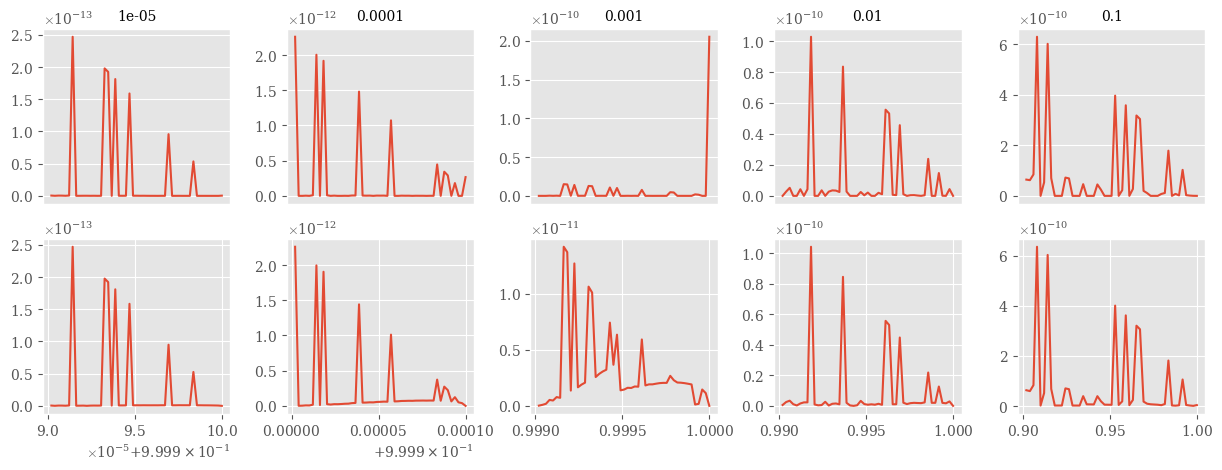

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (15,5) )

i = 0
for ε in np.logspace(-5,-1,5):
    A = np.linspace(1.0-ε, 1.0)[1:]
    B = np.asarray([integral_numeric(a, ε, eps=1e-14) for a in A])
    C = np.asarray([integral_numeric_b(a, ε, eps=1e-14) for a in A])
    D = integral_closed(A, ε).ravel()
    
    ax[0,i].plot(A, abs(B-D))
    ax[1,i].plot(A, abs(C-D))
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].set_xticks([])
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

In [12]:
# Compute convolution in all the domain
def G_closed(a, ε):
    """
    Computes G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA for x in (a,0) and a in [0,1]
    """
    x = np.abs(a)
    g = np.zeros_like(x)
    
    g[x <= 1.0 - ε] = 0.25 * ε**2 * (2.0 * np.log(ε) - 1.0)
    g[x >  1.0 - ε] = integral_closed(x[x > 1.0 - ε], ε).ravel()
    
    return g

In [13]:
def G(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA for x in (a,0) and a in [0,1]
    """
    x = abs(a)
    if x <= 1.0 - ε:
        g = 0.25 * ε**2 * (2.0 * np.log(ε) - 1.0)
    else:
        g = integral_numeric(x, ε, eps)
    return g

G_num = G

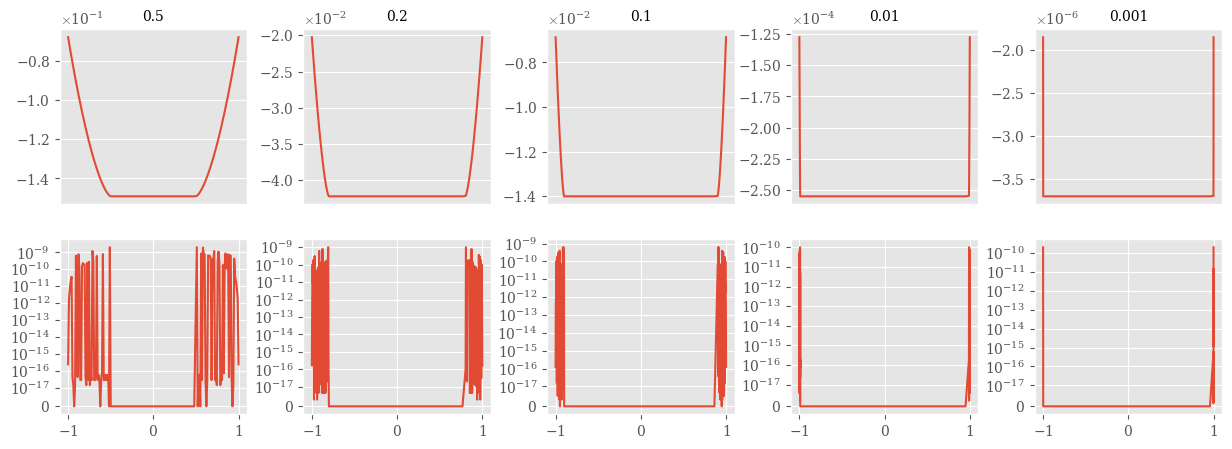

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (15,5))


i = 0
for ε in [0.5, 0.2, 0.1, 0.01, 0.001]:
    A = np.r_[np.linspace(-1.0, -1.0+ε)[:-1], np.linspace(-1.0+ε, 1.0-ε)[:-1], np.linspace(1.0-ε, 1.0)[1:]]
    B = G_closed(A, ε)
    C = np.asarray([G_num(a, ε, eps=1e-14) for a in A])
    
    ax[0,i].plot(A, B, label = r'$\int_{𝑥−●} K(u) \, \mathrm{d}u$' )
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    ax[0,i].set_xticks([])
    
    ax[1,i].plot(A, abs(B-C))
    ax[1,i].set_yscale('symlog', linthresh=1e-17)
    
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

In [15]:
# Present absolute error against quadrature
for ε in np.logspace(-1,-15,15):
    
    A = np.r_[np.linspace(-1.0, -1.0+ε)[:-1], np.linspace(-1.0+ε, 1.0-ε)[:-1], np.linspace(1.0-ε, 1.0)[1:]]
    
    B = np.asarray([G_num(a, ε, eps=1e-14) for a in A])
    C = G_closed(A, ε)
    
    print('{0:.0e}: {1:.2e}'.format(ε, np.linalg.norm(C-B)))

1e-01: 1.58e-09
1e-02: 2.30e-10
1e-03: 2.95e-10
1e-04: 5.77e-12
1e-05: 6.44e-13
1e-06: 6.34e-14
1e-07: 8.86e-15
1e-08: 1.11e-15
1e-09: 1.24e-17
1e-10: 1.37e-19
1e-11: 1.50e-21
1e-12: 1.64e-23
1e-13: 1.77e-25
1e-14: 1.92e-27
1e-15: 6.03e-29


---

## Direct derivation

$\newcommand{\dif}{\,\mathrm{d}}$
Recall that we aimed to compute 
\begin{align*}
    F_\varepsilon (a;\varphi) &= \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta 
    = \color{teal}{ \int\limits_0^\varphi \frac{1}{4(2\pi)} s^2(\theta) \big( \log s^2(\theta) - 1 \big) \dif \theta }.
    \end{align*}

In [16]:
ϕ, a = sp.symbols('ϕ, a', real=True, nonnegative = True)

In [17]:
sp.expand_func((-sp.im( sp.polylog(2, -a*sp.exp( 2*sp.I * ϕ)) )).diff(ϕ) ).rewrite(sp.cos).simplify()

log(a**2 + 2*a*cos(2*ϕ) + 1)

In [18]:
L_1 = sp.I * sp.polylog(2, -a*sp.exp( 2 *sp.I * ϕ))
L_2 = sp.I * sp.polylog(2, -a*sp.exp(-2 * sp.I * ϕ))

In [19]:
display( sp.expand_func(sp.diff(L_1, ϕ)), sp.expand_func(sp.diff(L_2, ϕ)) )

2*log(a*exp(2*I*ϕ) + 1)

-2*log(a*exp(-2*I*ϕ) + 1)

In [20]:
(sp.expand_func(sp.diff(L_1-L_2, ϕ))).rewrite(sp.cos).simplify()

2*log(a*exp(-2*I*ϕ) + 1) + 2*log(a*exp(2*I*ϕ) + 1)

Thus, we have that
\begin{align*}
    \int \log(1 + a^2 + 2a \cos 2\phi )  \dif \phi = \frac{i}{2} \big( \mathrm{Li}_2 (- a e^{2i \phi} ) - \mathrm{Li}_2 ( -a e^{-2i \phi} ) \big) + C
    = \boxed{- \Im \big( \mathrm{Li}_2 ( -a e^{2i \phi} ) \big) + C.}
\end{align*}

In [21]:
sp.expand_func((-sp.im( sp.polylog(2, -a*sp.exp( 2*sp.I * ϕ)) )).diff(ϕ) ).rewrite(sp.cos).simplify()

log(a**2 + 2*a*cos(2*ϕ) + 1)

In [22]:
-sp.im( sp.polylog(2, -a*sp.exp( 2*sp.I * ϕ)) )

-im(polylog(2, -a*exp(2*I*ϕ)))

---

\begin{align*}
    \int (a \cos 2\phi) \log(1 + a^2 + 2a \cos\phi )  \dif \phi = 
    \boxed{ \frac{1}{2} \left[ (1+a^2) \phi + (1-a^2)\arctan\left(\frac{ a-1}{a+1} \tan \phi\right) + a\big( \log(1+ a^2 +2a\cos 2\phi) - 1 \big)\sin 2\phi \right]  + C.}
\end{align*}

In [23]:
# We can verify the integral through symbolic differentiation
L_3a =  sp.S(1)/2 * ( (1 + a**2) * ϕ - (a**2 -1) * sp.atan( (-1 + a) * sp.sin(ϕ)/((1 + a) *sp.cos(ϕ)) ) + a *( sp.log(1 + a**2 + 2* a* sp.cos(2*ϕ)) - 1) * sp.sin(2 * ϕ))
display(L_3a)
L_3a.diff(ϕ).simplify().trigsimp(force=True)

a*(log(a**2 + 2*a*cos(2*ϕ) + 1) - 1)*sin(2*ϕ)/2 + ϕ*(a**2 + 1)/2 - (a**2 - 1)*atan((a - 1)*sin(ϕ)/((a + 1)*cos(ϕ)))/2

a*log(a**2 + 2*a*cos(2*ϕ) + 1)*cos(2*ϕ)

Alternative:
\begin{align*}
    \int (a\cos 2\phi)\log(1+a^2+2a\cos 2\phi) \, \dif \phi
    = \frac{1}{2} \left[ a\big( \ln(1 + a^2 + 2a \cos 2\phi) - 1\big) \sin 2\phi
    + 2a^2 \phi + (1 -a^2)\arctan\left(\frac{a\sin 2\phi}{1+a\cos 2\phi}\right)
  \right ] +
 C.
\end{align*}

In [24]:
L_3b =  sp.S(1)/2 * ( 2*(a**2) * ϕ + (1 - a**2) * sp.atan( a * sp.sin(2*ϕ)/(1 + a *sp.cos(2*ϕ)) ) + a *( sp.log(1 + a**2 + 2* a* sp.cos(2*ϕ)) - 1) * sp.sin(2 * ϕ))
display(L_3b)
L_3b.diff(ϕ).simplify().trigsimp(force=True)

a**2*ϕ + a*(log(a**2 + 2*a*cos(2*ϕ) + 1) - 1)*sin(2*ϕ)/2 + (1 - a**2)*atan(a*sin(2*ϕ)/(a*cos(2*ϕ) + 1))/2

a*log(a**2 + 2*a*cos(2*ϕ) + 1)*cos(2*ϕ)

---

The integral $H(a,\varphi)$ admits an alternative closed form 
\begin{equation}
\begin{aligned}
    F_\varepsilon (a;\varphi) &= \frac{1}{4 \pi} \bigg[
     \Im \big( \mathrm{Li}_2 (-a e^{2i\phi}) \big)
     + (1-a^2) \left[ \phi - \frac{1}{2}  \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]
    + \frac{a}{2} \big( 2- \log(1+ a^2 +2a\cos 2\phi)  \big)\sin 2\phi \bigg] \Bigg|_{ \phi(\varphi) }^{ \phi(\pi) } ,
\end{aligned}
\end{equation}
where $ \phi(\alpha) = \dfrac{1}{2} \arccos { \dfrac{s^2(\alpha) - 1- a^2 }{2a} } $.

\begin{align*}
    \varphi &= \arccos\frac{1 - a^2 - \varepsilon^2}{2 a \varepsilon},
    \qquad
    s(\theta) = -a \cos \theta + \sqrt{ 1 - a^2 \sin^2 \theta },
    \qquad
    1 - a^2 \sin^2 \varphi = \frac{ (1-a^2 + \varepsilon^2)^2 }{ 4\varepsilon^2},
    \qquad
    L(\theta) = \frac{s(\theta)^2 - 1 - a^2}{2a}
    \\
    s(\varphi) &= -\frac{1 - a^2 - \varepsilon^2}{2 \varepsilon} + \sqrt{ 1 - a^2 \sin^2 \varphi }
    = \frac{1}{2\varepsilon} \big[ (\varepsilon^2 + a^2 - 1) + |1 - a^2 + \varepsilon^2| \big]
    = \begin{cases}
            \varepsilon & \text{if } a^2 \leq 1 + \varepsilon^2,
            \\
            \dfrac{a^2 -1}{\varepsilon} & \text{if } a^2 > 1 + \varepsilon^2,
    \end{cases}
    \\
    L(\varphi) &=\begin{cases}
            \dfrac{ \varepsilon^2  - 1 - a^2}{ 2 a } & \text{if } a^2 \leq 1 + \varepsilon^2,
            \\
            \dfrac{ (a^2 - 1)^2 }{2 a \varepsilon^2} - \dfrac{1+a^2}{2a} & \text{if } a^2 > 1 + \varepsilon^2,
    \end{cases}
    \qquad \text{with special value } L(\varphi) \big|_{a=1\pm\varepsilon} = \pm 1.
    \\
    \phi(a,\varepsilon,\varphi) &= \frac{1}{2} \arccos L(\varphi) 
    \\
    s(0) &= 1-a, \qquad  L(0) = -1, \qquad \phi(a,\varepsilon,0) = \frac{\pi}{2}
    \\
    G\big(a;\phi(a,\varepsilon,0) \big) &=
    \underbrace{
	2 \Im \big( \mathrm{Li}_2 (-a e^{2i\phi}) \big)}_{0}
	+ 
    \underbrace{
    (1-a^2) \left[ 2 \phi - \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]}_{ (1-a^2) \pi }
	+ a\big( 2- \log(1+ a^2 +2a\cos 2\phi)  \big) \underbrace{\sin 2\phi}_{0} = (1-a^2) \pi + C.
\end{align*}

At $a = 1$, it holds that $\varphi = \arccos\frac{ - \varepsilon}{2} \sim \frac{\pi}{2}$. Clearly, $1 < 1+\varepsilon^2$, so $L(\varphi) = \frac{\varepsilon^2 - 2}{2}$.

In [25]:
def to_doubled_array(a):
    """
    - If `a` is an np.ndarray: return it unchanged.
    - If `a` is a number: return a 1-D float64 array of length 1.
    - If `a` is a list (or tuple): return it as a NumPy array.
    """
    if isinstance(a, np.ndarray):
        return a
    if np.isscalar(a):
        return np.array([a], dtype=np.float64)
    if isinstance(a, (list, tuple)):
        return np.asarray(a).astype(np.float64)
    raise TypeError(f"Unsupported type: {type(a)!r}")

In [26]:
def ϕ_from_a_ε(a,ε):
    # Range[a] = [1-ε, 1+ε];    Range[L] = [-1,1];    Range[ϕ] = ½[π,0]
    
    # Only needed for φ since ϕ(π) = 0 (Comes from s(π) = 1+a and L(π) = 1)
    L = 0.5 * (ε*ε - 1.0 - a*a) / a
    
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        c = 2.0 * b * np.square((b - 1.0/b) / (2.0*ε)) - 0.5 * (1.0 + b*b)/b
        np.clip(c, -1.0,1.0,c)
        L[checker] = c
        
    x = 0.5 * np.acos(L)
    return x

In [27]:
def G_half(a, ϕ):
    # Dilog term
    T_1 = spence( 1.0 + a * np.exp( 2j * ϕ) ).imag
    
    # Angular term
    arg_y = a * np.sin(2.0*ϕ)
    arg_x = 1.0 + a * np.cos(2.0*ϕ)
    T_2 = (1.0 - a*a) * ( ϕ - 0.5 * np.arctan2(arg_y, arg_x) )
    
    # Log term
    L = 1.0 + a*a + 2.0 * a * np.cos(2.0*ϕ)
    
    # Safe product to prevent issues with log
    T_3 = np.sin(2.0*ϕ)
    T_3[T_3 >= 1e-15] *= a[T_3 >= 1e-15] * (1.0 - 0.5 * np.log(L[T_3 >= 1e-15]) )
    #T_3 = a * (1.0 - 0.5 * np.log(L) ) * np.sin(2.0*ϕ)
    
    return T_1 + T_2 + T_3    
    
def H_4(a, ε):
    """
    Computes H(a) = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ    for a in (1-ε,1]
    """
    
    # Preprocess a
    a = to_doubled_array(a)
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
    
    # Compute φ (has the same size as a)
    φ = ϕ_from_a_ε(a, ε)
    
    # Compute half G:
    G  = G_half(a, φ)
    G *= 0.25/np.pi
    G -= 0.125 * (1-a*a)    # Take off G(a,ϕ(0)) which is exact
    
    return G

We compute the two implementations (labelled $H_3$ and $H_4$) and plot them below, where we use the auxiliary variable $\lambda$ so $a = \lambda + (1-\varepsilon)(1-\lambda)$.

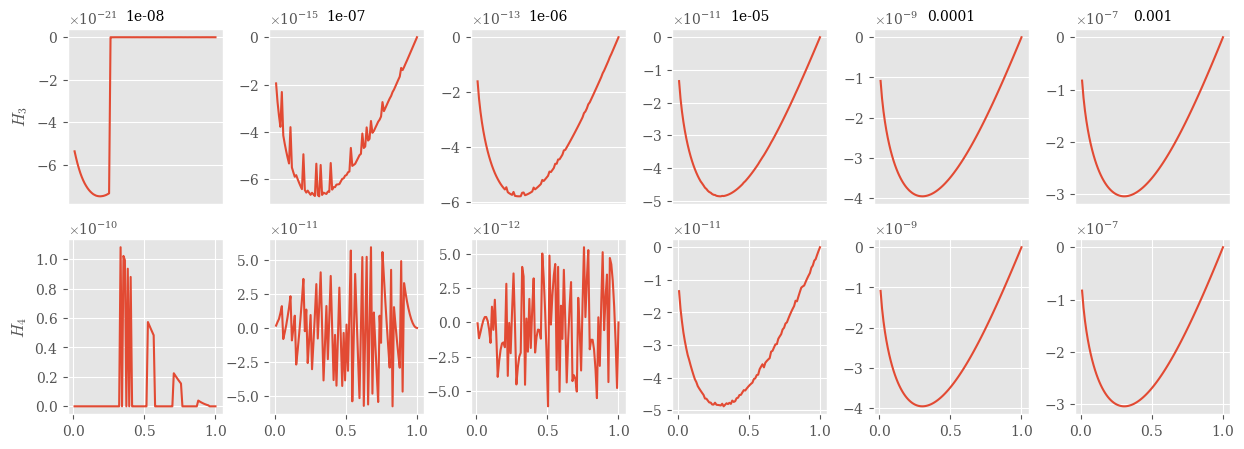

In [28]:
Λ = np.linspace(0.0, 1.0, 100)[1:]

fig, ax = plt.subplots(nrows=2, ncols=6, figsize = (15,5))

i = 0
for ε in np.logspace(-8,-3,6):  
    A = (1.0-ε)*(1.0-Λ) + 1.0*Λ                    #A = np.linspace(1.0-ε, (1.0+ε**2)**0.5)[1:]
    B = H_3(A,ε)# / (ε*ε*np.log(ε*ε))
    C = H_4(A,ε)# / (ε*ε*np.log(ε*ε))
    
    #ax[i].plot(A, C.T)
    ax[0,i].plot(Λ, B.T);    ax[0,i].set_title(ε, {'fontsize':10})
    ax[1,i].plot(Λ, C.T)
    
    ax[0,i].set_xticks([])
    #ax[i].set_yscale('symlog', linthresh= 1e-18)
    i += 1

ax[0,0].set_ylabel(r'$H_3$')
ax[1,0].set_ylabel(r'$H_4$')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

Observe that the original implementation (swapping the order of integration) results in a numerical evaluation of $F_\varepsilon$ that is more stable than the formula obtained using direct integration. Particularly, we observe how, already by $\varepsilon \leq 10^{-5}$, $H_4$ is prone to round-off error so that $\varepsilon \leq 10^{-6}$ essentially reports noise that no longer scales with $\varepsilon$. The same numerical issues occur later on for $H_3$, which is notisable for the case $\varepsilon = 10^{-7}$. 

Additionally, we can observe that $H_3$ seems to be converging under the scale $\varepsilon^2 \log \varepsilon^2$. This suggests the presence of an asymptotic limit which could be tested by a higher-precision implementation.

Let us test whether we can improve the numerical behaviour of $H_4$:

In [29]:
def sin_2ϕ_stable(a,ε):    
    '''
        First branch: a^2 ≤ 1 + ε^2
    '''
    
    δ = (a - 1.0)/ε
    t_1 = np.clip(1.0 - δ*δ, 0.0, None)                  # 1 - δ^2
    t_2 = np.clip(4.0*a + (δ*δ - 1.0)*ε*ε, 0.0, None)    # (2+δε)^2 - ε^2
    S = (0.5 * ε) * np.sqrt(t_1 * t_2) / a

    '''
        Second branch: a^2 > 1 + ε^2
    '''
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        δ = (b - 1.0) / ε
        t_1 = np.clip(1.0 - δ*δ, 0.0, None)                       # = 1 - δ^2
        t_2 = np.clip( 4*b + (δ*δ - 1.0)*ε*ε, 0.0, None)          # = 4a + (δ^2 - 1)ε^2
        n_p = δ * (b + 1.0)
        den = 2.0 * b
        
        S[checker] = n_p * np.sqrt(t_1 * t_2) / den
        
    return S
def acos2ϕ_approx(a,ε):
    '''
        Safely computes 0.5 * acos(cos2ϕ) down to ε = 4e-13
    '''
    δ = np.clip(a - 1.0, -1.0, 0.0)/ε            # = 1 - 2λ
    λ = np.clip( 0.5 * (1.0 - δ), 0.0, 1.0)
    E = 2 * λ * (1-λ)          # 2 - E ε^2 = 2 - 2λ (1-λ)ε^2 = 2(1 - λ (1-λ)ε^2)   ->   √(2 - E ε^2) = √2 √(1 - λ (1-λ)ε^2) ~ √2 ( 1 - y/2 - y^2/8 )
    #x = 2 * λ * (1-λ) * ε * ε
    
    ''' Option 1'''
    sqrt_x = E**0.5 * ε
    sqrt_d = np.sqrt( 2.0 - E * ε*ε )    # In double precision this is just 2 for tiny ε

    ϕ2 = np.atan2(sqrt_d, sqrt_x)
    ''' Option 2: Not really needed'''
    '''if ε < 1e-11:
        sqrt_2x = 0.5 * (2.0 * E)**0.5 * ε
        ϕ2 = 0.5 * np.pi - sqrt_2x
    '''
    
    return ϕ2

def H_stable(a, ε):
    """
    Stable H(a;eps) for small eps, with a in [1-eps, 1].
    """
    # Preprocess a
    a = to_doubled_array(a)
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
        
    '''
        Compute ϕ(φ), cos(2ϕ(φ)), and sin(2ϕ(φ))
    '''
    cos2ϕ = 0.5 * (ε*ε - 1.0 - a*a) / a
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        c = 2.0 * b * np.square((b - 1.0/b) / (2.0*ε)) - 0.5 * (1.0 + b*b)/b
        cos2ϕ[checker] = c
    np.clip(cos2ϕ, -1.0, 1.0, cos2ϕ)
    
    # Compute as many components as possible, then fix the ones with numerical issues
    ϕ = 0.5 * np.acos(cos2ϕ)
    if ε < 1e-4:
        if (~checker).any():
            ϕ[~checker] = acos2ϕ_approx(a[~checker],ε)
    
    #sin2ϕ = np.sqrt( np.clip(1.0 - cos2ϕ*cos2ϕ, 0.0, 1.0) )    # Use stable version instead:
    sin2ϕ = sin_2ϕ_stable(a,ε)
    
    '''
        Compute half G
    '''
    
    # Dilog term
    T_1 = spence( 1.0 + a * np.exp( 2j * ϕ) ).imag
    
    # Angular term
    T_2 = (1.0 - a*a) * ( ϕ - 0.5 * np.arctan2(a * sin2ϕ, 1 + a * cos2ϕ) )
    
    # Log term
    logL = np.full(a.size, 2.0 * np.log(ε))
    
    if checker.any():
        b = a[checker]
        logL[checker] = 2 * ( np.log( np.abs(b-1.0) ) + np.log(b+1) - np.log(ε) )
    
    T_3 = a * (1.0 - 0.5 * logL ) * sin2ϕ
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    '''
        Weight and shift
    '''
    G *= 0.25/np.pi
    G += 0.125 * (a*a-1.0)    # Take off G(a,ϕ(0)) which is exact. Alternatives: 0.125 (a-1)(a+1), -0.25(1-a) + 0.125(a-1)^2
    
    # Shift and weight
    '''S = (a*a-1.0) * (0.5 * np.pi) / (ε*ε)
    G /= (ε*ε)
    G += S
    G *= 0.25/np.pi
    G *= (ε*ε)'''
    
    
    
    # [T_1,T_3]/ε has a similar shape but does not "converge" in [1-ε, √(1+ε^2)]. 
    # [T_1,T_3] converges in [√(1+ε^2), 1+ε]
    # 
    #G = (T_1 + T_2 + T_3) * 0.25/np.pi
    #G = -0.25 * (a - 1.0)
    #G -= 0.25 *( (1.0 - a) + 0.5 * (a*a-1.0))
    
    return G

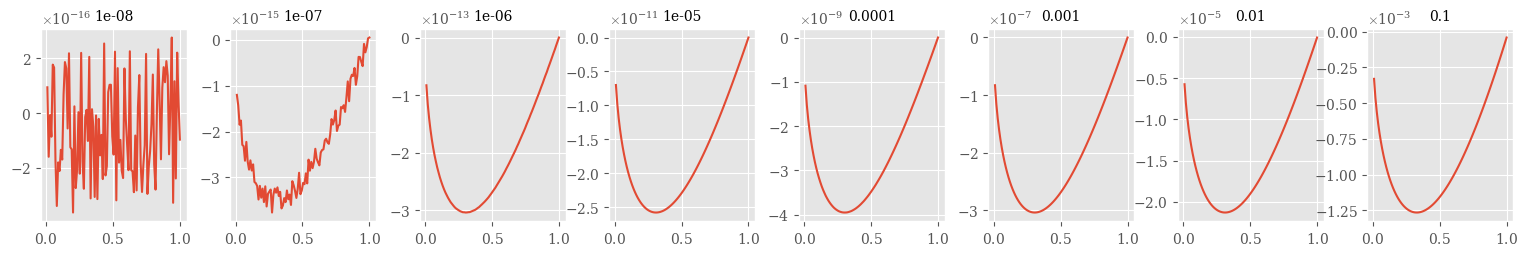

In [30]:
# Test
fig, ax = plt.subplots(nrows=1, ncols=8, figsize = (19,2.5))

i = 0
for ε in np.logspace(-8,-1,8):
    #A = np.linspace(1.0-ε, 1.0+ε)[1:]
    #A = np.linspace(1.0-ε, (1.0+ε**2)**0.5, 100)
    #A = np.linspace( (1.0+ε**2)**0.5, 1+ε)
    #A = np.linspace(1.0-ε, 1.0, 100)[1:]
    A = (1.0-ε)*(1.0-Λ) + 1.0*Λ                    #A = np.linspace(1.0-ε, (1.0+ε**2)**0.5)[1:]
    
    C = H_stable(A,ε)# / (ε*ε*np.log(ε*ε))
    ax[i].plot( Λ, (C))
    ax[i].set_title(ε, {'fontsize':10})
    ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

We observe that the new implementation of $H_4$, labelled $H_\text{stable}$, manages to improve the numerical evaluation of $F_\varepsilon$ down to $\varepsilon=10^{-6}$. In contrast, for $\varepsilon=10^{-7}$ numerical round-off error already limits the evaluation since we are working with values close to machine precision (using `double`). Observe that the code uses an approximation for $\cos 2\phi$. We will justify this next using an asymptotic expansion.

---

# Some asymptotics

When $\varepsilon$ is small, say below $10^{-6}$, computing $H=F_\varepsilon$ can become computationally challenging since evaluating $ \sin {2\Phi(\varphi)} $ and $ \cos {2\Phi(\varphi)} $ is susceptible to numerical instability.

First, observe the reduction
$
	\cos \big(2 \phi(\varphi) \big) = L(\varphi) .
$
The Pythagorean theorem yields
\begin{align*}
    \sin 2\Phi(\varphi) = 
    \begin{cases}
        \dfrac{1}{2a}  \sqrt{ ( (1+a)^2 - ε^2)  ( ε^2 - (1-a)^2 ) }
        & \text{if } a^2 \leq 1 + \varepsilon^2,
            \\
        \dfrac{1}{2a \varepsilon^{2}} \sqrt{\Big((a+1)^2\varepsilon^2 - (a^2-1)^2\Big) \Big((a^2-1)^2 - (a-1)^{2}\varepsilon^{2}\Big)}
        & \text{if } a^2 > 1 + \varepsilon^2.
    \end{cases}
\end{align*}


Introducing the notation $ \delta = \dfrac{a-1}{\varepsilon} $, we further obtain the numerically stable formulae
\begin{align*}
	\sin \big( 2\Phi(\varphi) \big) = 
	\begin{cases}
		\dfrac{\varepsilon}{2a}  \sqrt{ (1-\delta^2) \big( 4a + (\delta^2 -1) \varepsilon^2 \big) }
		 & \text{if } a^2 \leq 1 + \varepsilon^2,
		 \\[1em]
		 \dfrac{\delta (a+1)}{2a} \sqrt{ (1-\delta^2) \big( 4 a + (\delta^2 - 1) \varepsilon^2 \big) }
		 & \text{if } a^2 > 1 + \varepsilon^2.
	\end{cases}
\end{align*}

A particularly nice result for the lower layer is that if we take $ a_\varepsilon \in \big[1-\varepsilon, \sqrt{1+\varepsilon^2} \big] $, then it can be written as $ a_\varepsilon = \lambda (1-\varepsilon) + (1-\lambda) \sqrt{1+ \varepsilon^2} $ and $ \lim\limits_{\varepsilon \to 0} \delta = \lim\limits_{\varepsilon \to 0} \dfrac{( a_\varepsilon - 1 )}{\varepsilon} = -\lambda$. Similarly, we have that
\begin{align*}
	\lim_{\varepsilon \to 0}  \frac{ \sin \big( 2\Phi(\varphi)[a_\varepsilon] \big) }{\varepsilon}
	= \sqrt{ 1 - \lambda^2 }.
\end{align*}

The second branch is similar, with $ a_\varepsilon \in \big[\sqrt{1+\varepsilon^2}, 1+\varepsilon \big] $, $ \lim\limits_{\varepsilon \to 0} \delta = 1-\lambda$, and
\begin{align*}
	\lim_{\varepsilon \to 0}  \sin \big( 2\Phi(\varphi)[a_\varepsilon] \big) =
	2 (1-\lambda) \sqrt{\lambda(2-\lambda)}.
\end{align*}
Notice the absence of the division by $ \varepsilon $ in the last limit. For a point $ a_\varepsilon = (1-\lambda) (1-\varepsilon) + \lambda (1+ \varepsilon) $, then we have the joint result
\begin{align*}
	\begin{cases}
		\lim\limits_{\varepsilon \to 0} \dfrac{1}{\varepsilon} \left(1 + \sin \big( 2\Phi(\varphi)[a_\varepsilon] \big) \right) =
		2 \sqrt{\lambda (1-\lambda)} & \text{if }  \lambda < \frac 1 2 ,
		\\[1em]
		\lim\limits_{\varepsilon \to 0}  \sin \big( 2\Phi(\varphi)[a_\varepsilon] \big) =
		4(2\lambda - 1) \sqrt{ \lambda (1-\lambda) } & \text{if }  \lambda \geq \frac 1 2 .
	\end{cases}
\end{align*}

In [31]:
def sin_2ϕ(ε, opt=1):
    N = 100
    match opt:
        case 1:
            a = np.linspace(1.0-ε, 1.0, N)                   # a in [1-ε, 1]  [default]
        case 2:
            a = np.linspace(1.0-ε, 1.0+ε, N)                 # a in [1-ε, 1+ε]
        case 3:
            a = np.linspace(1.0-ε, (1.0 + ε*ε)**0.5, N)      # a in [1-ε, (1+ε)^½]
        case 4:
            a = np.linspace((1.0 + ε*ε)**0.5, 1.0+ε, N)      # a in [(1+ε)^½, 1+ε]
    
    '''
        First branch: a^2 ≤ 1 + ε^2
    '''
    #S = 0.5 * np.sqrt( np.clip( ((1.0+A)**2 - ε*ε) * ( ε*ε - (1.0-A)**2 ), 0.0, np.inf ) ) /A
    
    δ = (a - 1.0)/ε

    t_1 = np.clip(1.0 - δ*δ, 0.0, None)                  # 1 - δ^2
    t_2 = np.clip(4.0*a + (δ*δ - 1.0)*ε*ε, 0.0, None)    # (2+δε)^2 - ε^2
    
    den = a
    S = (0.5 * ε) * np.sqrt(t_1 * t_2) / den

    '''
        Second branch: a^2 > 1 + ε^2
    '''
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        #S[checker] = np.sqrt( ( (b+1.0)**2 * ε * ε - (b*b - 1.0)**2 ) * ( (b*b - 1.0)**2 - (b-1.0)**2 * ε *ε ) ) / (2 * b * ε * ε)
        
        δ = (b - 1.0) / ε
        t_1 = np.clip(1.0 - δ*δ, 0.0, None)                       # = 1 - δ^2
        #t_2 = np.clip((2.0 + δ*ε)**2 - ε*ε, 0.0, None)           # = (a+1)^2 - ε^2
        t_2 = np.clip( 4*b + (δ*δ - 1.0)*ε*ε, 0.0, None)          # = 4a + (δ^2 - 1)ε^2
        #n_p = np.abs(δ) * np.abs(2.0 + δ*ε)
        n_p = δ * (b + 1.0)
        den = 2.0 * b
        
        S[checker] = n_p * np.sqrt(t_1 * t_2) / den
        
    return S

Asymptotics of $\sin \big(2\phi(\varphi) \big)$  as $\varepsilon \to 0$:

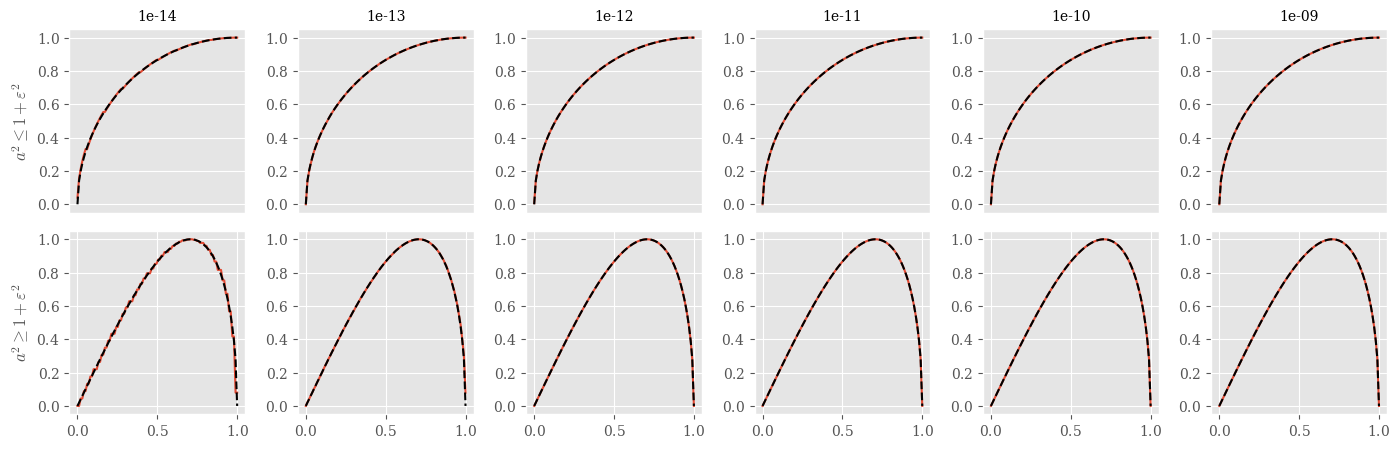

In [32]:
fig, ax = plt.subplots(nrows=2, ncols=6, figsize = (17,5))

Λ_1, Λ_2 = np.linspace(-1.0, 0, 100), np.linspace(0, 1, 100)
C_1 = np.sqrt(1 - Λ_1**2)
C_2 = 2.0 * Λ_2 * np.sqrt( (1.0 - Λ_2) * (1.0 + Λ_2) ) # 2 (1-λ) \sqrt{λ(2-λ)} → [1-λ] → 2 λ \sqrt{(1-λ)(1+λ) }

i = 0
for ε in np.logspace(-14,-9,6):
    B_1 = sin_2ϕ(ε,3)/ε
    B_2 = sin_2ϕ(ε,4)
    
    ax[0,i].plot(Λ_1, B_1);        ax[0,i].plot(Λ_1, C_1, '--', c='black')
    ax[1,i].plot(Λ_2, B_2);        ax[1,i].plot(Λ_2, C_2, '--', c='black')
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].set_xticks([])
    #ax[i].set_yscale('symlog', linthresh= 1e-18)
    i += 1
    
ax[0,0].set_ylabel(r'$a^2 \leq 1+ \varepsilon^2$')
ax[1,0].set_ylabel(r'$a^2 \geq 1+ \varepsilon^2$')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.1)

We can check the expansion for a very small $\varepsilon$:

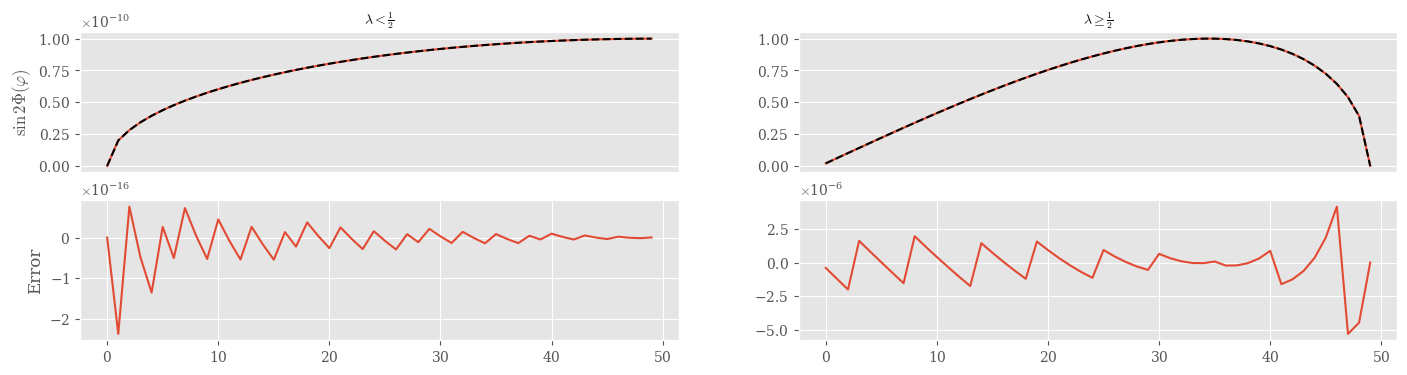

In [33]:
# Asymptotics of sine
N = 100
ε = 1e-10
A = np.linspace(1.0-ε, 1.0+ε, N)
Λ = np.linspace(0,1,N)
B = sin_2ϕ(ε,2)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize = (17,4))

ax[0,0].plot(0.5*((A - 1)/ε + 1)[:50], B[:50])    # We can recover [0,1] by shifting the scaled interval
#ax[0,0].plot(Λ[:50], 2 * Λ[Λ <= 0.5] *(1 - Λ[Λ <= 0.5]) * ε*ε - 1,  '--', c='black')
ax[0,0].plot(Λ[:50], 2.0 * (Λ[Λ <= 0.5] *(1 - Λ[Λ <= 0.5]))**0.5 * ε,  '--', c='black')

ax[0,1].plot(0.5*((A - 1)/ε + 1)[50:], B[50:])
ax[0,1].plot(Λ[50:], -4.0*(1.0-2.0*Λ[50:]) * (Λ[50:] *(1.0-Λ[50:]) )**0.5,  '--', c='black')

ax[1,0].plot(B[:50] - 2.0 * (Λ[Λ <= 0.5] *(1 - Λ[Λ <= 0.5]))**0.5 * ε )
ax[1,1].plot(B[50:] + 4.0*(1.0-2.0*Λ[50:]) * (Λ[50:] *(1.0-Λ[50:]) )**0.5 )


ax[0,0].set_title(r'$\lambda < \frac{1}{2}$', {'fontsize':10});       ax[0,0].set_xticks([])
ax[0,1].set_title(r'$\lambda \geq \frac{1}{2}$', {'fontsize':10});    ax[0,1].set_xticks([])

ax[0,0].set_ylabel(r'$\sin 2\Phi(\varphi)$')
ax[1,0].set_ylabel(r'Error')
#plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
plt.show()

---

Similarly, we can arrive at
\begin{align*}
	\begin{cases}
		\lim\limits_{\varepsilon \to 0}  \dfrac{1}{\varepsilon^2} \left( 1 + \cos \big( 2\Phi(\varphi)[a_\varepsilon] \big) \right) =
		2 \lambda (1-\lambda) & \text{if } \lambda < \frac 1 2 ,
		% \lambda (1- \lambda/2) for \delta \to -\lambda
		\\
		\lim_{\varepsilon \to 0}  \cos \big( 2\Phi(\varphi)[a_\varepsilon] \big) =
		1 + 8 \lambda(\lambda - 1) &  \text{if }  \lambda \geq \frac 1 2 .
		% 1 - 4\lambda + \lambda^2 for \delta \to 1-\lambda
	\end{cases}
\end{align*}
The former comes from the relation
$\left(
	\dfrac{ \varepsilon^2  - 1 - a^2}{ 2 a }  = -1 + \dfrac{ (1-\delta^2) \varepsilon^2 }{ 2(1 + \delta \varepsilon) }
\right)$.
Notice that if $ \varepsilon < 10^{-6} $, the quantity $ 2 \lambda (1-\lambda) \varepsilon^2 $ is already below machine precision. As a result, it is possible to use the approximation
\begin{align*}
	\arccos (x - 1) = 2 \arctan( \sqrt{2-x} / \sqrt{x} ) \approx \pi - \sqrt{2 x} - \frac{ x^{\frac{3}{2}} }{6 \sqrt{2}} + O( x^{\frac{5}{3}} ).
\end{align*}


In [34]:
def cos_2ϕ(ε, opt=1):
    N = 100
    match opt:
        case 1:
            a = np.linspace(1.0-ε, 1.0, N)                   # a in [1-ε, 1]  [default]
        case 2:
            a = np.linspace(1.0-ε, 1.0+ε, N)                 # a in [1-ε, 1+ε]
        case 3:
            a = np.linspace(1.0-ε, (1.0 + ε*ε)**0.5, N)      # a in [1-ε, (1+ε)^½]
        case 4:
            a = np.linspace((1.0 + ε*ε)**0.5, 1.0+ε, N)      # a in [(1+ε)^½, 1+ε]
    
    '''
        First branch: a^2 ≤ 1 + ε^2
    '''
    # Works for ε ≥ 1e-7
    cos2ϕ = 0.5 * (ε*ε - 1.0 - a*a) / a
    # For ε < 1e-7
    if ε < 1e-6:
        δ = (a - 1.0)/ε            # = 1 - 2λ
        λ = 0.5 * (1 - δ)
        E = 2 * λ * (1-λ)
        cos2ϕ = E * ε * ε - 1.0    # Will cancel in double precision
        
    
    checker = (np.square(a) > 1.0 + ε*ε)
    if checker.any():
        b = a[checker]
        c = 2.0 * b * np.square((b - 1.0/b) / (2.0*ε)) - 0.5 * (1.0 + b*b)/b
        cos2ϕ[checker] = c
        if ε < 1e-13:
            δ = (b - 1.0)/ε        # Will cancel in double precision
            λ = 0.5 * (1 - δ)
            E = 1 + 8 * λ * (λ - 1.0)
            cos2ϕ[checker] = E
        
    np.clip(cos2ϕ, -1.0, 1.0, cos2ϕ)
    
    return cos2ϕ

Asymptotics of $\cos \big(2\Phi(\varphi) \big)$  as $\varepsilon \to 0$:

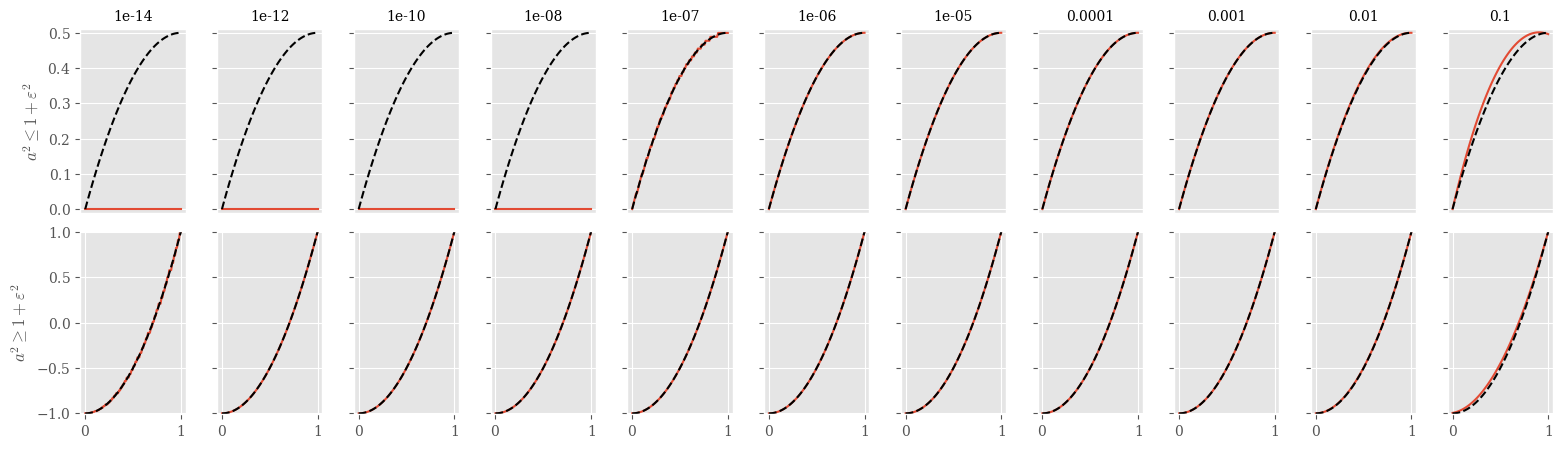

In [35]:
fig, ax = plt.subplots(nrows=2, ncols=11, figsize = (19,5))

Λ_1, Λ_2 = np.linspace(-1.0, 0, 100), np.linspace(0, 1, 100)
C_1 = 0.5 * (1 - Λ_1**2) #(Λ+1) * (1 - 0.5*(Λ+1))
C_2 = -3 + 4.0 * Λ_2 + 2 * (1-Λ_2)**2 #(Λ+1) * (1 - 0.5*(Λ+1))

i = 0
E_p = np.logspace(-14,-1,14)
for ε in np.r_[E_p[:7][::2], E_p[7:]]:
    B_1 = (cos_2ϕ(ε,3) + 1)/(ε*ε)
    B_2 = cos_2ϕ(ε,4)
    
    ax[0,i].plot(Λ_1, B_1);        ax[0,i].plot(Λ_1, C_1, '--', c='black')
    ax[1,i].plot(Λ_2, B_2);        ax[1,i].plot(Λ_2, C_2, '--', c='black')
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].set_xticks([])
    #ax[i].set_yscale('symlog', linthresh= 1e-18)
    
    if i > 0:
        #ax[0,i].set_yticks([])
        ax[0,i].set_yticklabels([])
        ax[1,i].set_yticklabels([])
    ax[0,i].set_ylim([-1e-2,0.51])
    ax[1,i].set_ylim([-1-1e-2,1.01])
    
    i += 1
    
ax[0,0].set_ylabel(r'$a^2 \leq 1+ \varepsilon^2$')
ax[1,0].set_ylabel(r'$a^2 \geq 1+ \varepsilon^2$')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.1)

We can check the expansion for a very small $\varepsilon$:

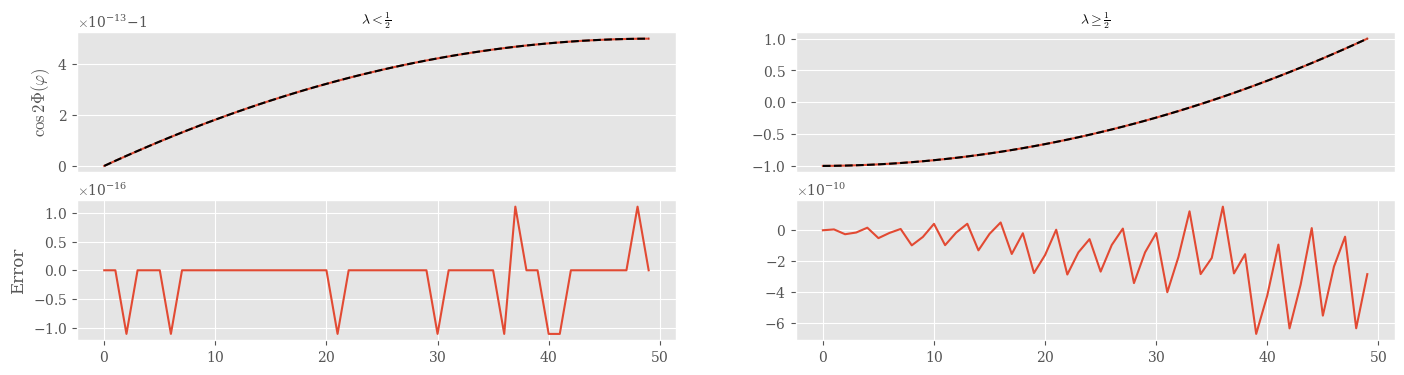

In [36]:
# Asymptotics of sine
N = 100
ε = 1e-6
A = np.linspace(1.0-ε, 1.0+ε, N)
Λ = np.linspace(0,1,N)
B = cos_2ϕ(ε,2)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize = (17,4))

ax[0,0].plot(0.5*((A - 1)/ε + 1)[:50], B[:50])    # We can recover [0,1] by shifting the scaled interval
ax[0,0].plot(Λ[:50], 2 * Λ[Λ <= 0.5] *(1 - Λ[Λ <= 0.5]) * ε*ε - 1,  '--', c='black')

ax[0,1].plot(0.5*((A - 1)/ε + 1)[50:], B[50:])
ax[0,1].plot(Λ[50:], 1 + 8 * Λ[Λ > 0.5] *(Λ[Λ > 0.5] - 1) ,  '--', c='black')

ax[1,0].plot(B[:50] - (2 * Λ[Λ <= 0.5] *(1 - Λ[Λ <= 0.5]) * ε*ε - 1)  )
ax[1,1].plot(B[50:] - (1 + 8 * Λ[Λ > 0.5] *(Λ[Λ > 0.5] - 1)) )


ax[0,0].set_title(r'$\lambda < \frac{1}{2}$', {'fontsize':10});       ax[0,0].set_xticks([])
ax[0,1].set_title(r'$\lambda \geq \frac{1}{2}$', {'fontsize':10});    ax[0,1].set_xticks([])

ax[0,0].set_ylabel(r'$\cos 2\Phi(\varphi)$')
ax[1,0].set_ylabel(r'Error')
#plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
plt.show()

---